In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mne
from scipy import signal, stats, optimize
import logging
from typing import Dict, List, Tuple, Optional
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import json
import warnings

In [2]:
features = pd.read_csv("eeg_features.csv")
features.head()

,subject_id,rpl_alpha,resting_alpha_power,resting_total_power,alpha_power_c3,alpha_power_c4,alpha_asymmetry,rpl_lower_beta,resting_lower_beta_power,rpl_upper_beta,...,pse_C4,pse_Cz,pse_avg,lzc_C3,lzc_C4,lzc_Cz,lzc_avg,theta_power,alpha_power,tar
0,S001,0.194741,8.242792e-12,4.232705e-11,6.628976e-12,1.039650e-11,0.450019,0.079778,3.376770e-12,0.086238,...,0.988388,0.994204,0.986577,0.002716,0.009505,0.013579,0.008600,5.685271e-12,6.728552e-12,0.053269
1,S002,0.202166,7.847295e-12,3.881609e-11,6.816839e-12,4.408732e-12,-0.435809,0.112889,4.381919e-12,0.209611,...,0.998837,0.987766,0.994784,0.005431,0.002716,0.021726,0.009958,3.514686e-12,3.428552e-12,0.033982
2,S003,0.099183,3.021946e-10,3.046833e-09,1.990851e-11,8.757055e-10,3.783883,0.061178,1.863987e-10,0.043745,...,0.952386,0.995225,0.976120,0.002716,0.005431,0.002716,0.003621,3.611554e-10,1.693918e-10,1.340632
3,S004,0.094906,2.162228e-12,2.278282e-11,2.793310e-12,2.282966e-12,-0.201752,0.075321,1.716026e-12,0.063961,...,0.999230,0.999874,0.999133,0.002716,0.002716,0.006789,0.004074,3.195265e-12,1.595437e-12,0.031451
4,S005,0.058463,4.349915e-12,7.440495e-11,4.316240e-12,5.436551e-12,0.230760,0.059404,4.419965e-12,0.042856,...,0.991964,0.998913,0.995943,0.105913,0.002716,0.109986,0.072872,7.541399e-12,4.122103e-12,0.072428


In [3]:
features.shape

(109, 41)

In [4]:
labels = pd.read_csv("ground_truth_cv_labels.csv")
labels.head()

,subject_id,mean_accuracy
0,S001,0.511111
1,S002,0.777778
2,S003,0.511111
3,S004,0.444444
4,S005,0.400000


In [5]:
labels.shape

(109, 2)

In [6]:
df = features.merge(labels, on = 'subject_id', how = 'inner')
df.head(5)

,subject_id,rpl_alpha,resting_alpha_power,resting_total_power,alpha_power_c3,alpha_power_c4,alpha_asymmetry,rpl_lower_beta,resting_lower_beta_power,rpl_upper_beta,...,pse_Cz,pse_avg,lzc_C3,lzc_C4,lzc_Cz,lzc_avg,theta_power,alpha_power,tar,mean_accuracy
0,S001,0.194741,8.242792e-12,4.232705e-11,6.628976e-12,1.039650e-11,0.450019,0.079778,3.376770e-12,0.086238,...,0.994204,0.986577,0.002716,0.009505,0.013579,0.008600,5.685271e-12,6.728552e-12,0.053269,0.511111
1,S002,0.202166,7.847295e-12,3.881609e-11,6.816839e-12,4.408732e-12,-0.435809,0.112889,4.381919e-12,0.209611,...,0.987766,0.994784,0.005431,0.002716,0.021726,0.009958,3.514686e-12,3.428552e-12,0.033982,0.777778
2,S003,0.099183,3.021946e-10,3.046833e-09,1.990851e-11,8.757055e-10,3.783883,0.061178,1.863987e-10,0.043745,...,0.995225,0.976120,0.002716,0.005431,0.002716,0.003621,3.611554e-10,1.693918e-10,1.340632,0.511111
3,S004,0.094906,2.162228e-12,2.278282e-11,2.793310e-12,2.282966e-12,-0.201752,0.075321,1.716026e-12,0.063961,...,0.999874,0.999133,0.002716,0.002716,0.006789,0.004074,3.195265e-12,1.595437e-12,0.031451,0.444444
4,S005,0.058463,4.349915e-12,7.440495e-11,4.316240e-12,5.436551e-12,0.230760,0.059404,4.419965e-12,0.042856,...,0.998913,0.995943,0.105913,0.002716,0.109986,0.072872,7.541399e-12,4.122103e-12,0.072428,0.400000


# Columns

In [7]:
for i in df.columns:
    print(i)

subject_id
rpl_alpha
resting_alpha_power
resting_total_power
alpha_power_c3
alpha_power_c4
alpha_asymmetry
rpl_lower_beta
resting_lower_beta_power
rpl_upper_beta
resting_upper_beta_power
smr_strength
IAF_c3
alpha_peak_amp_c3
beta_peak_amp_c3
beta_center_freq_c3
aperiodic_exp_c3
IAF_c4
alpha_peak_amp_c4
beta_peak_amp_c4
beta_center_freq_c4
aperiodic_exp_c4
alpha_var_C3
alpha_cv_C3
alpha_var_C4
alpha_cv_C4
coherence_mu
coherence_beta
coherence_low_beta
coherence_upper_beta
pse_C3
pse_C4
pse_Cz
pse_avg
lzc_C3
lzc_C4
lzc_Cz
lzc_avg
theta_power
alpha_power
tar
mean_accuracy


# Missing Values

In [8]:
missing_val_cols = []
for col in df.columns:
    if df[col].isna().sum() > 0:
        missing_val_cols.append(col)
        print(missing_val_cols[-1], ": ", df[col].isna().sum())


IAF_c3 :  50
IAF_c4 :  49


In [9]:
missing_df = df[['IAF_c3', 'IAF_c4']]
missing_df

,IAF_c3,IAF_c4
0,11.978944,NaN
1,11.726630,9.076708
2,NaN,NaN
3,NaN,10.131501
4,NaN,NaN
...,...,...
104,10.323881,NaN
105,NaN,9.757377
106,8.702243,9.736001
107,10.847895,10.807177


In [10]:
# check how many rows have at least one missing value
missing_df[(missing_df['IAF_c3'].isna()) | (missing_df['IAF_c4'].isna())]

,IAF_c3,IAF_c4
0,11.978944,NaN
2,NaN,NaN
3,NaN,10.131501
4,NaN,NaN
5,NaN,8.790012
...,...,...
100,NaN,NaN
103,NaN,9.197972
104,10.323881,NaN
105,NaN,9.757377


### Notes:
 - subjects with missing values in C3 or C4 are not the same . Many different subjects have one or both missing values from either electrode
 - missingness in those columns is caused by edge values for IAF, which are unreliable and best kept missing
 - Resting Alpha Power and IAF are related. For missing values, Resting alpha power can instead be used
 - About half of the rows have at least one missing value (over half, 66/109 = 61%)
 - Missingness Mechanism: Not Missing at Random (NMAR), because whether or not a value is missing depends on what that value would have been

# Initial dropping of redundant columns

In [11]:
to_drop = [
    'resting_alpha_power', # captured by rpl_alpha
    'resting_total_power', # captured by rpl_alpha
    'alpha_power_c3', # captured by rpl_alpha
    'alpha_power_c4',
    'resting_lower_beta_power', # captured by rpl_lower_beta
    'resting_upper_beta_power', # captured by rpl_upper_beta
    'coherence_beta', # captured by coherence_lower/upper_beta
    'pse_C3', # captured by pse_avg
    'pse_C4',
    'pse_Cz',
    'lzc_C3', # captured by lzc_avg
    'lzc_C4',
    'lzc_Cz',
    'theta_power', # captured by tar
    'alpha_power', # captured by tar
]

In [12]:
df = df.drop(columns = to_drop)

In [13]:
df.head(5)

,subject_id,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,alpha_peak_amp_c3,beta_peak_amp_c3,beta_center_freq_c3,...,alpha_cv_C3,alpha_var_C4,alpha_cv_C4,coherence_mu,coherence_low_beta,coherence_upper_beta,pse_avg,lzc_avg,tar,mean_accuracy
0,S001,0.194741,0.450019,0.079778,0.086238,7.022793,11.978944,22.815138,12.760082,23.819507,...,0.061019,4.663400e-12,0.043488,0.141332,0.123185,0.109485,0.986577,0.008600,0.053269,0.511111
1,S002,0.202166,-0.435809,0.112889,0.209611,5.940523,11.726630,10.176643,34.331115,22.893572,...,0.024698,1.433725e-12,0.014019,0.175965,0.135896,0.144874,0.994784,0.009958,0.033982,0.777778
2,S003,0.099183,3.783883,0.061178,0.043745,4.247568,NaN,51.445281,7.098251,19.972889,...,0.046159,2.667545e-10,0.415862,0.123387,0.122145,0.121065,0.976120,0.003621,1.340632,0.511111
3,S004,0.094906,-0.201752,0.075321,0.063961,3.151023,NaN,79.301217,18.015913,23.955119,...,0.008185,7.108965e-13,0.006985,0.125134,0.110144,0.149414,0.999133,0.004074,0.031451,0.444444
4,S005,0.058463,0.230760,0.059404,0.042856,3.573126,NaN,51.986931,18.888159,19.707314,...,0.014593,3.416010e-12,0.031799,0.167894,0.148708,0.111603,0.995943,0.072872,0.072428,0.400000


# Averaging C3/C4 columns

In [14]:
for i in df.columns:
    print(i)

subject_id
rpl_alpha
alpha_asymmetry
rpl_lower_beta
rpl_upper_beta
smr_strength
IAF_c3
alpha_peak_amp_c3
beta_peak_amp_c3
beta_center_freq_c3
aperiodic_exp_c3
IAF_c4
alpha_peak_amp_c4
beta_peak_amp_c4
beta_center_freq_c4
aperiodic_exp_c4
alpha_var_C3
alpha_cv_C3
alpha_var_C4
alpha_cv_C4
coherence_mu
coherence_low_beta
coherence_upper_beta
pse_avg
lzc_avg
tar
mean_accuracy


In [15]:
# IAF avg - will actually keep both for now because of missing values

In [16]:
# Alpha peak amp
df['alpha_peak_amp'] = (df['alpha_peak_amp_c3'] + df['alpha_peak_amp_c4']) / 2

In [17]:
# beta peak amp
df['beta_peak_amp'] = (df['beta_peak_amp_c3'] + df['beta_peak_amp_c4']) / 2

In [18]:
# beta center freq
df['beta_center_freq'] = (df['beta_center_freq_c3'] + df['beta_center_freq_c4']) / 2

In [19]:
# aperiodic_exp_c4
df['aperiodic_exp'] = (df['aperiodic_exp_c3'] + df['aperiodic_exp_c4']) / 2

In [20]:
# alpha var
df['alpha_var'] = (df['alpha_var_C3'] + df['alpha_var_C4']) / 2

In [21]:
# alpha cv
df['alpha_cv'] = (df['alpha_cv_C3'] + df['alpha_cv_C4']) / 2

In [22]:
to_drop_avg = [
    'alpha_peak_amp_c3',
    'alpha_peak_amp_c4',
    'beta_peak_amp_c3',
    'beta_peak_amp_c4',
    'beta_center_freq_c3',
    'beta_center_freq_c4',
    'aperiodic_exp_c3',
    'aperiodic_exp_c4',
    'alpha_var_C3',
    'alpha_var_C4',
    'alpha_cv_C3',
    'alpha_cv_C4'
]

In [23]:
df = df.drop(columns = to_drop_avg)

In [24]:
df.head(5)

,subject_id,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,...,pse_avg,lzc_avg,tar,mean_accuracy,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv
0,S001,0.194741,0.450019,0.079778,0.086238,7.022793,11.978944,NaN,0.141332,0.123185,...,0.986577,0.008600,0.053269,0.511111,42.163593,9.505743,18.409753,0.5,5.632592e-12,0.052254
1,S002,0.202166,-0.435809,0.112889,0.209611,5.940523,11.726630,9.076708,0.175965,0.135896,...,0.994784,0.009958,0.033982,0.777778,27.169969,58.070694,23.234802,0.5,1.996023e-12,0.019358
2,S003,0.099183,3.783883,0.061178,0.043745,4.247568,NaN,NaN,0.123387,0.122145,...,0.976120,0.003621,1.340632,0.511111,72.389867,14.524291,22.830159,0.5,1.360196e-10,0.231010
3,S004,0.094906,-0.201752,0.075321,0.063961,3.151023,NaN,10.131501,0.125134,0.110144,...,0.999133,0.004074,0.031451,0.444444,73.945146,11.901924,22.401534,0.5,7.746218e-13,0.007585
4,S005,0.058463,0.230760,0.059404,0.042856,3.573126,NaN,NaN,0.167894,0.148708,...,0.995943,0.072872,0.072428,0.400000,29.900526,39.299466,16.353657,0.5,2.463477e-12,0.023196


In [25]:
df['bci_performance_labels'] = df['mean_accuracy']
df = df.drop(columns = ['mean_accuracy'])
df.head(5)

,subject_id,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,...,pse_avg,lzc_avg,tar,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv,bci_performance_labels
0,S001,0.194741,0.450019,0.079778,0.086238,7.022793,11.978944,NaN,0.141332,0.123185,...,0.986577,0.008600,0.053269,42.163593,9.505743,18.409753,0.5,5.632592e-12,0.052254,0.511111
1,S002,0.202166,-0.435809,0.112889,0.209611,5.940523,11.726630,9.076708,0.175965,0.135896,...,0.994784,0.009958,0.033982,27.169969,58.070694,23.234802,0.5,1.996023e-12,0.019358,0.777778
2,S003,0.099183,3.783883,0.061178,0.043745,4.247568,NaN,NaN,0.123387,0.122145,...,0.976120,0.003621,1.340632,72.389867,14.524291,22.830159,0.5,1.360196e-10,0.231010,0.511111
3,S004,0.094906,-0.201752,0.075321,0.063961,3.151023,NaN,10.131501,0.125134,0.110144,...,0.999133,0.004074,0.031451,73.945146,11.901924,22.401534,0.5,7.746218e-13,0.007585,0.444444
4,S005,0.058463,0.230760,0.059404,0.042856,3.573126,NaN,NaN,0.167894,0.148708,...,0.995943,0.072872,0.072428,29.900526,39.299466,16.353657,0.5,2.463477e-12,0.023196,0.400000


# Correlation between columns

In [26]:
correlation_matrix = df.drop(columns = ['subject_id']).corr()
correlation_matrix

,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,coherence_upper_beta,pse_avg,lzc_avg,tar,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv,bci_performance_labels
rpl_alpha,1.000000,0.081695,0.302155,0.234915,0.711264,0.305401,0.175095,0.340435,0.160128,0.105395,-0.421454,-0.013972,-0.178203,-0.088539,0.108142,-0.193105,-0.127680,0.058705,0.159210,0.442414
alpha_asymmetry,0.081695,1.000000,-0.013343,-0.139819,0.006906,0.301222,0.101497,0.057676,-0.012933,0.078052,-0.151031,-0.013902,0.531234,0.079074,-0.124324,-0.027082,-0.058937,0.518355,0.275347,-0.009266
rpl_lower_beta,0.302155,-0.013343,1.000000,0.564004,0.377726,0.182116,0.238941,0.172093,0.184541,0.102975,-0.147205,-0.004813,-0.178969,-0.059837,0.381015,0.133619,0.190197,0.085343,-0.152689,0.192863
rpl_upper_beta,0.234915,-0.139819,0.564004,1.000000,0.110340,0.137282,0.259959,0.266522,0.193642,0.242335,0.219587,0.055687,-0.290768,-0.279510,0.439740,0.321699,0.469736,-0.035246,-0.309151,0.059611
smr_strength,0.711264,0.006906,0.377726,0.110340,1.000000,0.266605,0.294220,0.158443,0.021964,0.004390,-0.656271,-0.012610,-0.112577,0.102135,0.360665,-0.235803,-0.242486,0.023708,0.275797,0.401878
IAF_c3,0.305401,0.301222,0.182116,0.137282,0.266605,1.000000,0.171875,0.248299,0.025942,0.109500,-0.109730,-0.235403,-0.173666,-0.026978,0.023078,0.020593,0.089018,-0.027852,-0.022433,0.284085
IAF_c4,0.175095,0.101497,0.238941,0.259959,0.294220,0.171875,1.000000,0.044656,0.148609,0.004248,-0.082677,-0.055768,-0.350616,-0.157368,0.255263,0.168128,0.104165,-0.128375,-0.153045,0.145316
coherence_mu,0.340435,0.057676,0.172093,0.266522,0.158443,0.248299,0.044656,1.000000,0.305187,0.377159,-0.057044,0.083460,-0.160820,-0.200923,-0.032203,-0.102473,0.183106,-0.064954,-0.089365,0.156497
coherence_low_beta,0.160128,-0.012933,0.184541,0.193642,0.021964,0.025942,0.148609,0.305187,1.000000,0.446310,0.144289,0.101994,-0.255520,-0.087549,0.110152,0.000652,0.159857,-0.109537,-0.263231,0.104801
coherence_upper_beta,0.105395,0.078052,0.102975,0.242335,0.004390,0.109500,0.004248,0.377159,0.446310,1.000000,-0.006644,0.020097,-0.155709,-0.206545,0.061887,0.159855,0.326341,-0.124254,-0.042054,-0.024916


In [27]:
for col in correlation_matrix.columns:
    for i in range(len(correlation_matrix)):
        if np.isclose(correlation_matrix[col].iloc[i], 1.0):
            continue
        elif np.abs(correlation_matrix[col].iloc[i]) > 0.65:
            print(f"{col:<30} {correlation_matrix.index[i]:<30} {correlation_matrix[col].iloc[i]:>10.3f}")

rpl_alpha                      smr_strength                        0.711
smr_strength                   rpl_alpha                           0.711
smr_strength                   pse_avg                            -0.656
pse_avg                        smr_strength                       -0.656
pse_avg                        alpha_cv                           -0.718
alpha_cv                       pse_avg                            -0.718


# Correlation Notes:

## Correlation notes (Old and irrelevant): 
## ***!!!(note: these notes were done before df cols were filtered for redundancy and averages)
- cols with consistently high correlation:
  - resting_alpha_power
  - resting_total_power
  - alpha_power_c4
  - resting_lower_beta_power
  - resting_upper_beta_power
  - alpha_var_C4
  - theta_power
  - alpha_power

- Also
  - alpha_var_c3 and alpha_cv_c3 are highly correlated (0.99) with each other
  - coherence_veta and coherence_upper_beta are highly correlated (0.919) with each other
  - pse_C3, pse_C4, and pse_avg are highly correlated via pse_avg (c3 and c4 not extremely correlated with each other)


Options I am considering:
- keeping one col per correlation block
  - If I keep resting alpha, the only other columns I keep are: alpha_cv_c3, pse_avg,
     - -> leads to resting_alpha_power, alpha_cv_c3, pse_avg
     - -> columns to drop: ["resting_total_power", "alpha_power_c4", "resting_lower_beta_power",
       "resting_upper_beta_power", "alpha_var_C4", "theta_power", "alpha_power", "alpha_var_C3",
       "coherence_beta", "coherence_upper_beta", "pse_C3", "pse_C4"]

- Ridge regression
- LASSO (automatic subset selection)
- Elastic net
- PCA to reduce dimensionality

In [28]:
# redundant = ["resting_total_power", "alpha_power_c4", "resting_lower_beta_power", "resting_upper_beta_power", 
#              "alpha_var_C4", "theta_power", "alpha_power", "alpha_var_C3", "coherence_beta", 
#              "coherence_upper_beta", "pse_C3", "pse_C4"]
# df_dropped_redundant = df[[col for col in df.columns if col not in redundant]]
# df_dropped_redundant.head()

### Interesting: rpl_alpha not correlated with resting alpha or total power, when it is the quotient of those
- direct algebraic dependence, which can be bad with my small N (109)

In [29]:
df['rpl_alpha'].describe()

count    109.000000
mean       0.155202
std        0.097238
min        0.037214
25%        0.093260
50%        0.121682
75%        0.190014
max        0.454908
Name: rpl_alpha, dtype: float64

### Notes to remember:
- use either rpl or absolute power consistently
- avg c3 and c4 features

In [30]:
df.head(5)

,subject_id,rpl_alpha,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,...,pse_avg,lzc_avg,tar,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv,bci_performance_labels
0,S001,0.194741,0.450019,0.079778,0.086238,7.022793,11.978944,NaN,0.141332,0.123185,...,0.986577,0.008600,0.053269,42.163593,9.505743,18.409753,0.5,5.632592e-12,0.052254,0.511111
1,S002,0.202166,-0.435809,0.112889,0.209611,5.940523,11.726630,9.076708,0.175965,0.135896,...,0.994784,0.009958,0.033982,27.169969,58.070694,23.234802,0.5,1.996023e-12,0.019358,0.777778
2,S003,0.099183,3.783883,0.061178,0.043745,4.247568,NaN,NaN,0.123387,0.122145,...,0.976120,0.003621,1.340632,72.389867,14.524291,22.830159,0.5,1.360196e-10,0.231010,0.511111
3,S004,0.094906,-0.201752,0.075321,0.063961,3.151023,NaN,10.131501,0.125134,0.110144,...,0.999133,0.004074,0.031451,73.945146,11.901924,22.401534,0.5,7.746218e-13,0.007585,0.444444
4,S005,0.058463,0.230760,0.059404,0.042856,3.573126,NaN,NaN,0.167894,0.148708,...,0.995943,0.072872,0.072428,29.900526,39.299466,16.353657,0.5,2.463477e-12,0.023196,0.400000


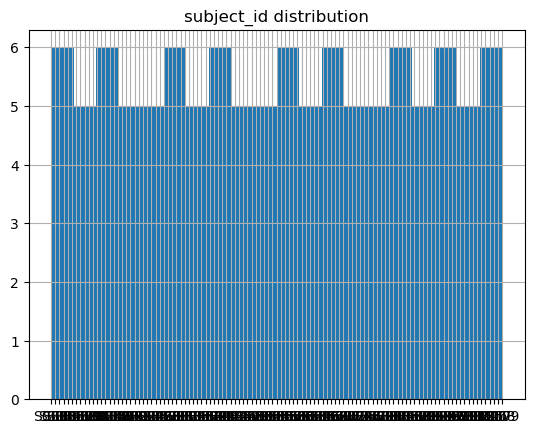

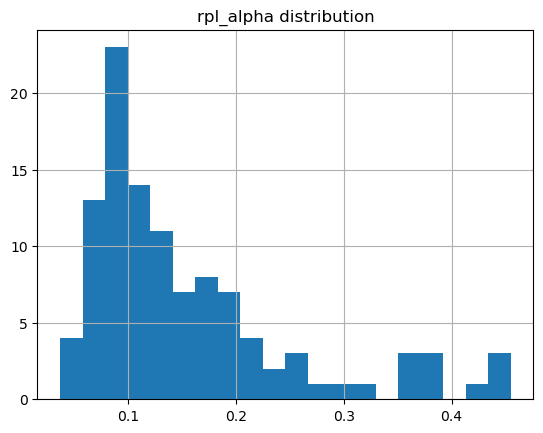

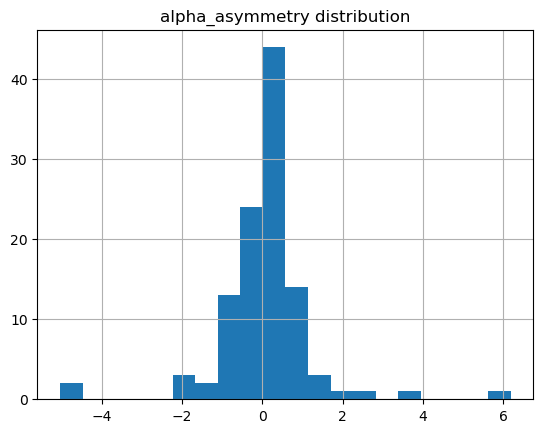

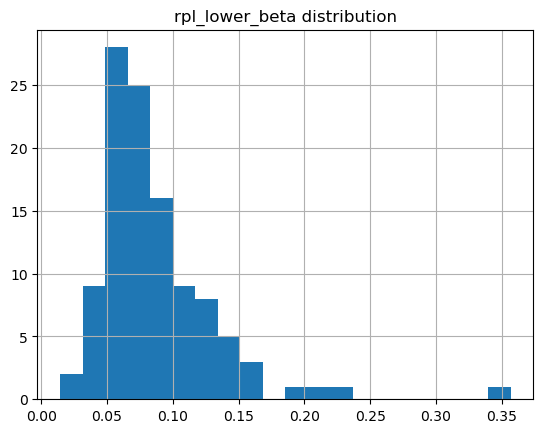

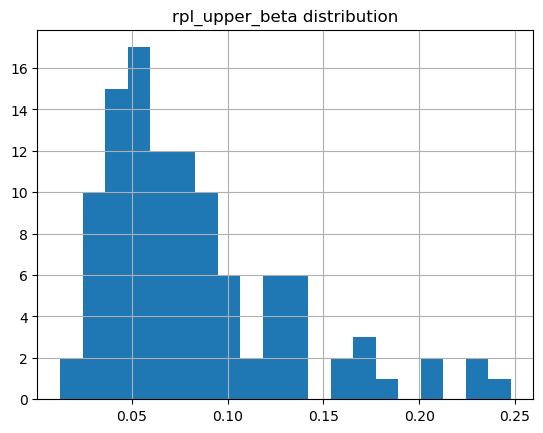

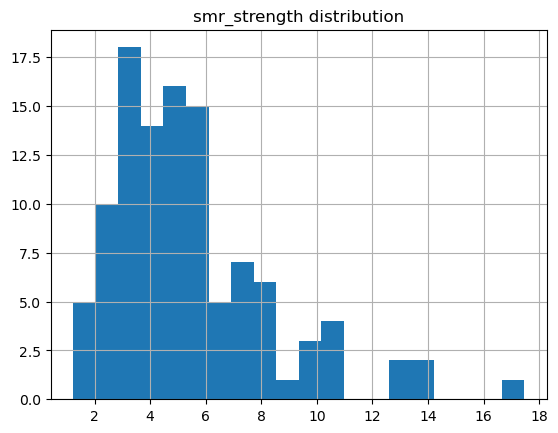

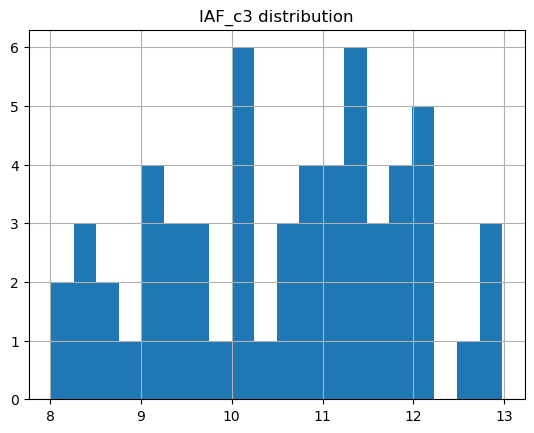

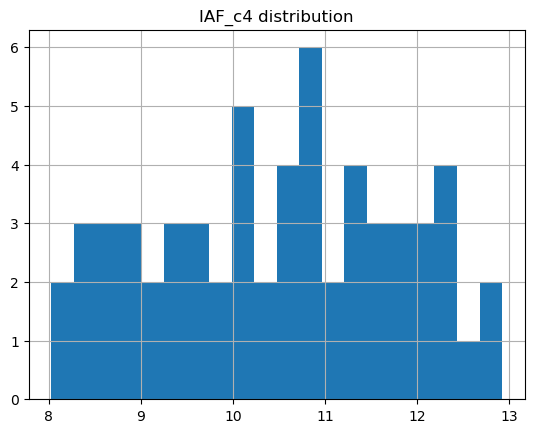

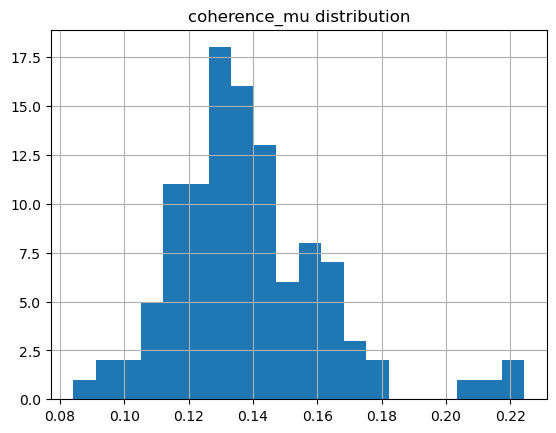

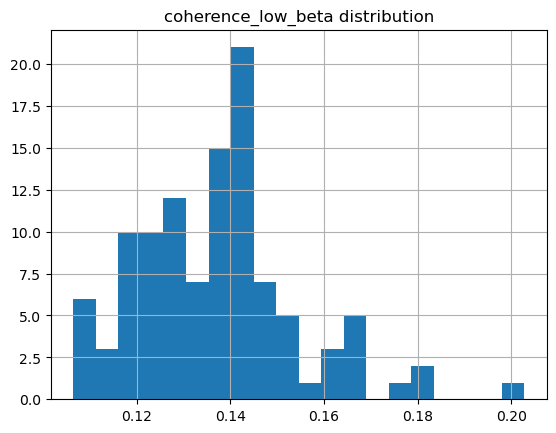

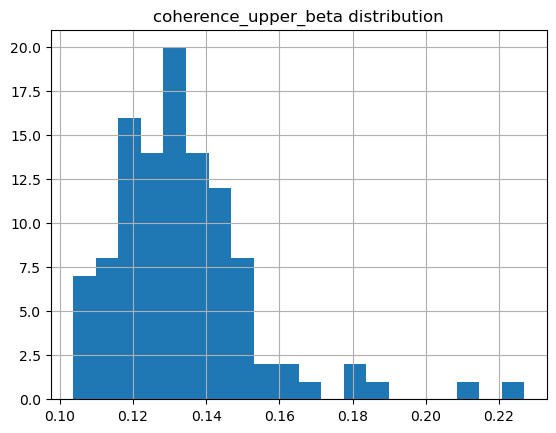

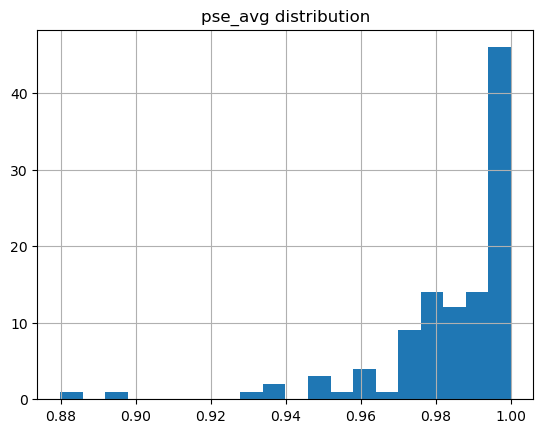

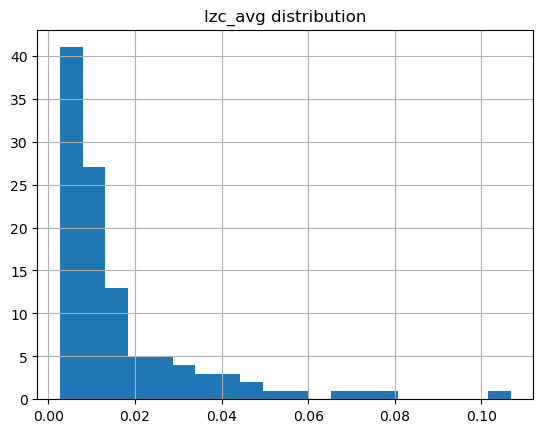

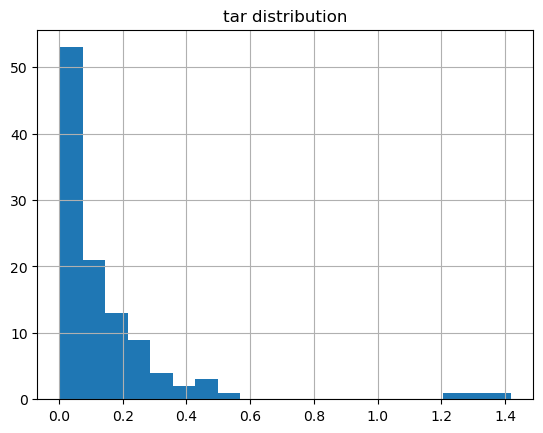

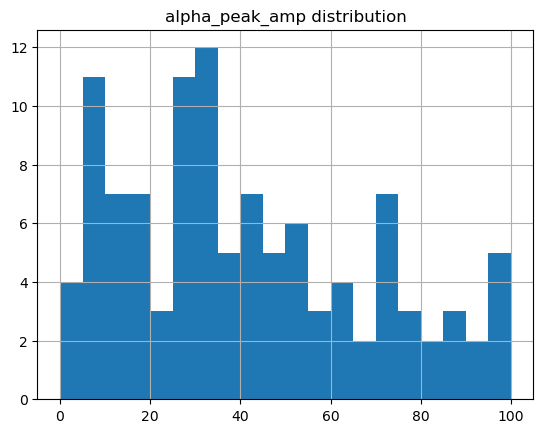

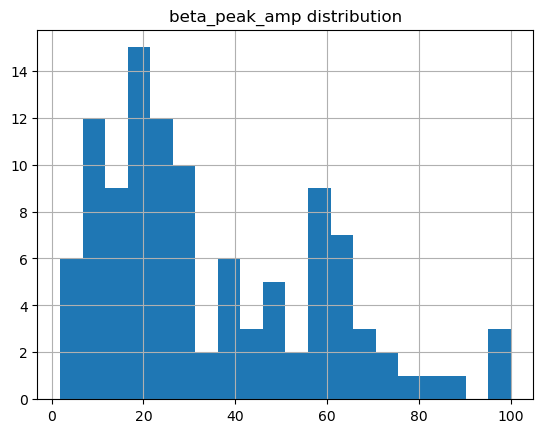

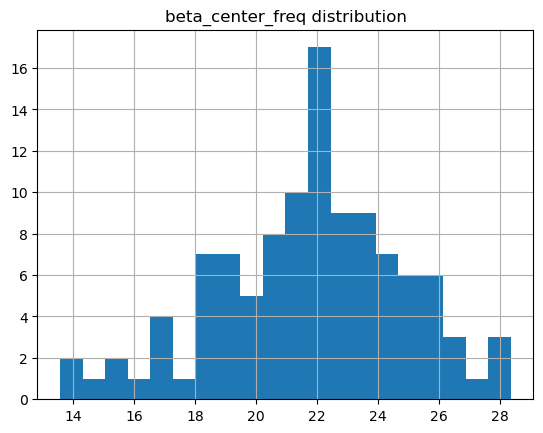

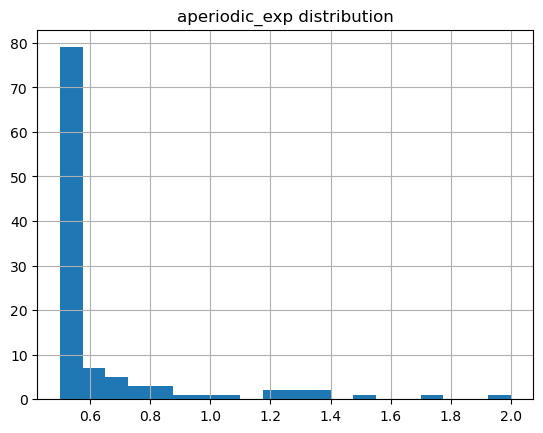

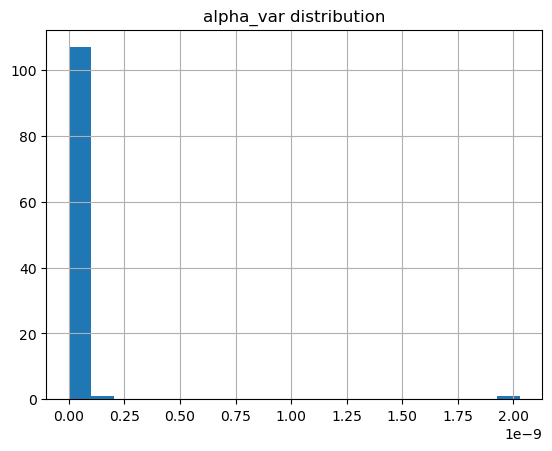

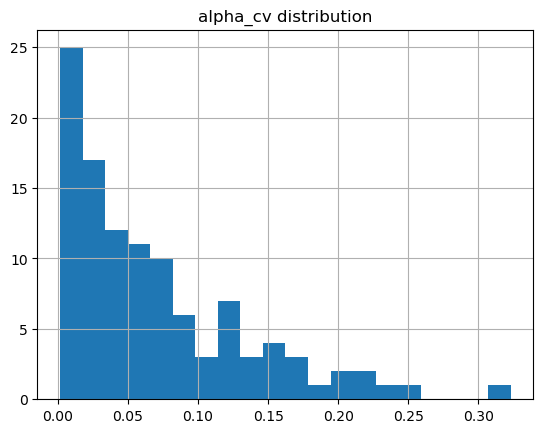

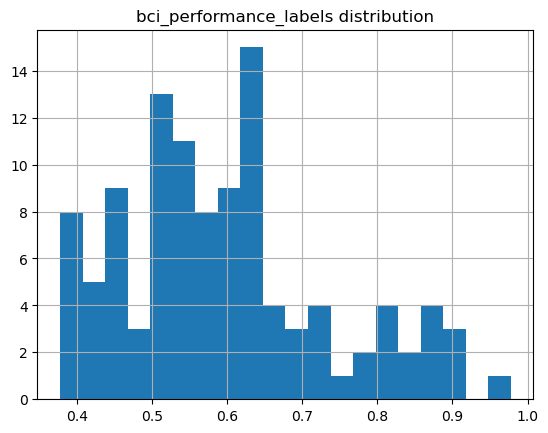

In [31]:
for col in df.columns:
    plt.figure()
    df[col].hist(bins = 20)
    plt.title(f"{col} distribution")
    plt.show()

In [32]:
df['alpha_var'].describe()

count    1.090000e+02
mean     2.849211e-11
std      1.941418e-10
min      1.515316e-13
25%      1.996023e-12
50%      5.435652e-12
75%      1.238221e-11
max      2.029498e-09
Name: alpha_var, dtype: float64

In [33]:
df['log_alpha_var'] = np.log10(df['alpha_var'])
df = df.drop(columns = ['alpha_var'])

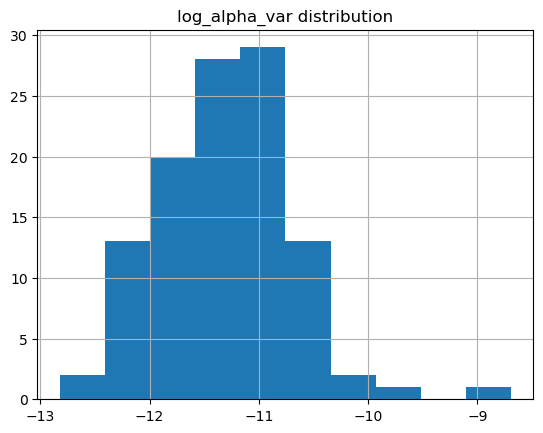

In [34]:
# alpha_var on improper axes
plt.figure()
df['log_alpha_var'].hist()
plt.title('log_alpha_var distribution')
plt.show()

# Next step: feature transformations according to distributions

In [ ]:
# end goal: decide on ridge regression or boosting/RF